In [1]:
import pynq
pynq.PL.reset()
ol= pynq.Overlay("nodma_1.bit")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
samples = 1250000

In [76]:
import time
my_list=[]
ol.reg_bank_0.write(0x40,samples)
ol.reg_bank_0.write(0x44,1)
ol.reg_bank_0.write(0x44,0)
ol.double_derivative_top_0.write(0x00, 1)
print(ol.double_derivative_top_0.read(0x00))

while(1):
    if ol.double_derivative_top_0.read(0x00) & 0x2:
        print(ol.double_derivative_top_0.read(0x00))
        num_1    = ol.double_derivative_top_0.read(0x10)
        num_2    = ol.double_derivative_top_0.read(0x14)
        den_1    = ol.double_derivative_top_0.read(0x28)
        den_2    = ol.double_derivative_top_0.read(0x2c)
        break

num = np.int64((num_2 << 32) | (num_1 & 0xFFFFFFFF))
den = np.int64((den_2 << 32) | (den_1 & 0xFFFFFFFF))

import math
dt = 1.0 / 1e6
A  = num / den if den != 0 else 0
#f_est = math.sqrt(A) / (4 * math.pi * dt) if A > 0 else 0
f_est = np.arcsin(np.sqrt(A / 4)) / (np.pi*2 * dt)
print(f"Estimated f0: {f_est:.2f} Hz")
  # undo the 1e9 scaling

print(A)
print(num,den)
ol.double_derivative_top_0.write(0x00, 0)
my_list.append(f_est)
time.sleep(2)

1
4
Estimated f0: 100001.67 Hz
1.3820058245340734
6231780020176 4509228477584


In [25]:
def to_int64(high, low):
    val = (high << 32) | (low & 0xFFFFFFFF)
    if high & 0x80000000:  # sign bit of upper 32 bits
        val -= 1 << 64
    return np.int64(val)

In [71]:
import time
import numpy as np
samples = 625000
my_list = []
time_list = []
avg_time=[]
t1=time.time()

for i in range(0, 500):
    avg_time.append(time.time()-t1)
    t_start = time.time()

    ol.reg_bank_0.write(0x40,samples)
    ol.reg_bank_0.write(0x44,1)
    ol.reg_bank_0.write(0x44,0)
    ol.double_derivative_top_0.write(0x00, 1)
    #print(ol.double_derivative_top_0.read(0x00))

    while(1):
        if ol.double_derivative_top_0.read(0x00) & 0x2:
            #print(ol.double_derivative_top_0.read(0x00))
            num_1    = ol.double_derivative_top_0.read(0x10)
            num_2    = ol.double_derivative_top_0.read(0x14)
            den_1    = ol.double_derivative_top_0.read(0x28)
            den_2    = ol.double_derivative_top_0.read(0x2c)
            break

    num = np.int64((num_2 << 32) | (num_1 & 0xFFFFFFFF))
    den = np.int64((den_2 << 32) | (den_1 & 0xFFFFFFFF))
#     num = to_int64(num_2, num_1)
#     den = to_int64(den_2, den_1)

    import math
    dt = 1.0 / 1e6
    A  = float(num) / float(den) if den != 0 else 0
    #f_est = math.sqrt(A) / (4 * math.pi * dt) if A > 0 else 0
    f_est = np.arcsin(np.sqrt(A / 4)) / (np.pi*2 * dt)

    ol.double_derivative_top_0.write(0x00, 0)

    t_elapsed = time.time() - t_start
    # excludes sleep
    t1=time.time()

    print(f"[{i:03d}] f0={f_est} Hz  A={A:.6f}  num={num}  den={den}  t={t_elapsed*1000:.1f}ms")

    my_list.append(f_est)
    time_list.append(t_elapsed)


# ── Summary ───────────────────────────────────────────────────
print(f"\nTiming summary:")
print(f"  Mean  : {np.mean(time_list)*1000:.1f} ms")
print(f"  Min   : {np.min(time_list)*1000:.1f} ms")
print(f"  Max   : {np.max(time_list)*1000:.1f} ms")
print(np.mean(avg_time))


[000] f0=100001.83784866793 Hz  A=1.382010  num=3112934023104  den=2252468619088  t=5.9ms
[001] f0=100001.95345545864 Hz  A=1.382013  num=3113695504560  den=2253015109824  t=6.8ms
[002] f0=100001.76837633442 Hz  A=1.382008  num=3115150604144  den=2254075209648  t=5.6ms
[003] f0=100001.88859385102 Hz  A=1.382011  num=3113787092976  den=2253083909152  t=5.7ms
[004] f0=100001.71554844092 Hz  A=1.382007  num=3113283172128  den=2252726022784  t=5.7ms
[005] f0=100001.77068879172 Hz  A=1.382008  num=3112493742928  den=2252152655536  t=5.7ms
[006] f0=100001.55648225153 Hz  A=1.382003  num=3115214831888  den=2254129944928  t=5.7ms
[007] f0=100001.69311743602 Hz  A=1.382006  num=3112659690560  den=2252275754464  t=5.6ms
[008] f0=100001.69214242397 Hz  A=1.382006  num=3113507420224  den=2252889197440  t=5.6ms
[009] f0=100001.68883134655 Hz  A=1.382006  num=3113585194400  den=2252945602736  t=5.6ms
[010] f0=100001.48942339933 Hz  A=1.382002  num=3114386779568  den=2253533390496  t=5.7ms
[011] f0=1

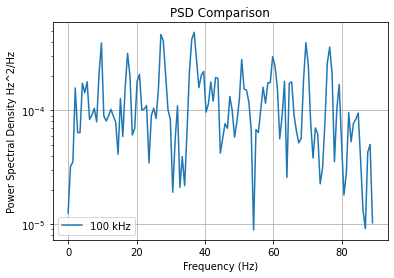

In [72]:
freq= np.array(my_list)
fs = 1 / np.mean(time_list)
f3, Pxx3 = welch(freq, fs=fs, nperseg=256)
plt.figure()
plt.semilogy(f3, Pxx3, label="100 kHz")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density Hz^2/Hz")
plt.title("PSD Comparison")
plt.grid()
plt.legend()

plt.show()


Enter input frequency in Hz (or q to quit): 10000
Input = 10000.000 Hz
Estimated = 10002.486 Hz
Error = 2.486 Hz
Time = 6.5 ms

Enter input frequency in Hz (or q to quit): 20000
Input = 20000.000 Hz
Estimated = 20001.338 Hz
Error = 1.338 Hz
Time = 5.7 ms

Enter input frequency in Hz (or q to quit): 30000
Input = 30000.000 Hz
Estimated = 30001.345 Hz
Error = 1.345 Hz
Time = 5.9 ms

Enter input frequency in Hz (or q to quit): 40000
Input = 40000.000 Hz
Estimated = 40001.328 Hz
Error = 1.328 Hz
Time = 5.7 ms

Enter input frequency in Hz (or q to quit): 50000
Input = 50000.000 Hz
Estimated = 50001.235 Hz
Error = 1.235 Hz
Time = 5.7 ms

Enter input frequency in Hz (or q to quit): 60000
Input = 60000.000 Hz
Estimated = 60001.536 Hz
Error = 1.536 Hz
Time = 5.7 ms

Enter input frequency in Hz (or q to quit): 70000
Input = 70000.000 Hz
Estimated = 70001.384 Hz
Error = 1.384 Hz
Time = 5.8 ms

Enter input frequency in Hz (or q to quit): 80000
Input = 80000.000 Hz
Estimated = 80001.503 Hz
Error =

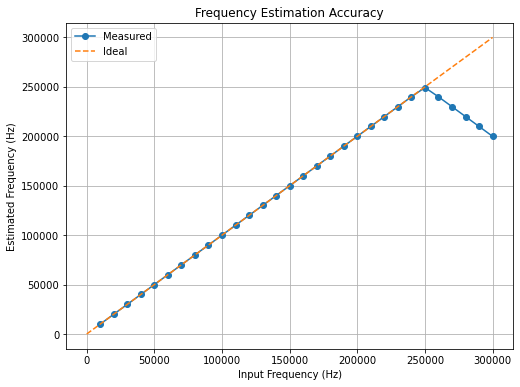

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Plot setup
# --------------------------------------------------
plt.ion()

fig, ax = plt.subplots(figsize=(8, 6))

input_freqs = []
estimated_freqs = []

line, = ax.plot([], [], 'o-', label='Measured')
ideal_line, = ax.plot([], [], '--', label='Ideal')

ax.set_xlabel("Input Frequency (Hz)")
ax.set_ylabel("Estimated Frequency (Hz)")
ax.set_title("Frequency Estimation Accuracy")
ax.grid(True)
ax.legend()

# --------------------------------------------------
# Main loop
# --------------------------------------------------
while True:

    freq_in = input("\nEnter input frequency in Hz (or q to quit): ")

    if freq_in.lower() == 'q':
        break

    freq_in = float(freq_in)

    # ==================================================
    # Your existing measurement code starts here
    # ==================================================

    samples = 625000

    t_start = time.time()

    ol.reg_bank_0.write(0x40, samples)
    ol.reg_bank_0.write(0x44, 1)
    ol.reg_bank_0.write(0x44, 0)

    ol.double_derivative_top_0.write(0x00, 1)

    while True:
        if ol.double_derivative_top_0.read(0x00) & 0x2:

            num_1 = ol.double_derivative_top_0.read(0x10)
            num_2 = ol.double_derivative_top_0.read(0x14)

            den_1 = ol.double_derivative_top_0.read(0x28)
            den_2 = ol.double_derivative_top_0.read(0x2C)

            break

    num = np.int64((num_2 << 32) | (num_1 & 0xFFFFFFFF))
    den = np.int64((den_2 << 32) | (den_1 & 0xFFFFFFFF))

    dt = 1.0 / 1e6

    A = float(num) / float(den) if den != 0 else 0

    f_est = np.arcsin(np.sqrt(A / 4)) / (2 * np.pi * dt)

    ol.double_derivative_top_0.write(0x00, 0)

    elapsed = time.time() - t_start

    # ==================================================
    # Your existing measurement code ends here
    # ==================================================

    print(f"Input = {freq_in:.3f} Hz")
    print(f"Estimated = {f_est:.3f} Hz")
    print(f"Error = {f_est - freq_in:.3f} Hz")
    print(f"Time = {elapsed*1000:.1f} ms")

    # Store all previous runs
    input_freqs.append(freq_in)
    estimated_freqs.append(f_est)

    # Update plot
    line.set_data(input_freqs, estimated_freqs)

    max_freq = max(input_freqs + estimated_freqs)
    ideal_line.set_data([0, max_freq], [0, max_freq])

    ax.relim()
    ax.autoscale_view()

    fig.canvas.draw()
    fig.canvas.flush_events()

plt.ioff()
plt.show()

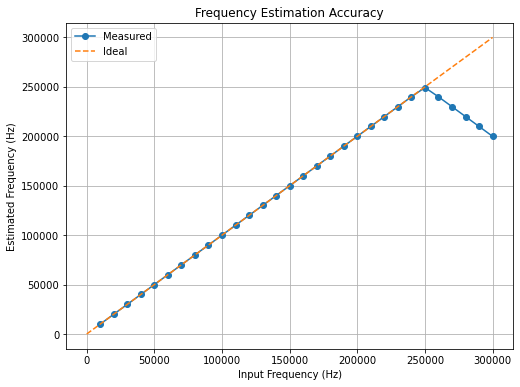

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(input_freqs, estimated_freqs, 'o-', label='Measured')

m = max(input_freqs + estimated_freqs)
plt.plot([0, m], [0, m], '--', label='Ideal')

plt.xlabel("Input Frequency (Hz)")
plt.ylabel("Estimated Frequency (Hz)")
plt.title("Frequency Estimation Accuracy")
plt.grid(True)
plt.legend()

plt.savefig("frequency_estimation_accuracy.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [11]:
import pandas as pd
import numpy as np

# Convert to arrays (safer for math)
input_arr = np.array(input_freqs)
est_arr = np.array(estimated_freqs)

# Compute error
error_arr = est_arr - input_arr

# Create table
df = pd.DataFrame({
    "Input_Frequency (Hz)": input_arr,
    "Estimated_Frequency (Hz)": est_arr,
    "Error (Hz)": error_arr
})

df.round(3)

,Input_Frequency (Hz),Estimated_Frequency (Hz),Error (Hz)
0,10000.0,10002.486,2.486
1,20000.0,20001.338,1.338
2,30000.0,30001.345,1.345
3,40000.0,40001.328,1.328
4,50000.0,50001.235,1.235
5,60000.0,60001.536,1.536
6,70000.0,70001.384,1.384
7,80000.0,80001.503,1.503
8,90000.0,90001.750,1.750
9,100000.0,100001.936,1.936
